# Part 3 - Advanced Machine Learning
In part one we achieved around 67% accuracy on GalaxyMNIST using a kNN-classifier. Ultimately our goal is to get the highest possible score on GalaxyMNIST which can most likely be achieved using Convolutional Neural Networks. It is good practice to compare against simple baselines when developing more complex models. In this notebook, we will start with simple non-neural network classifiers and then move on to fully connected and convolutional neural networks.

In [1]:
%load_ext autoreload
%autoreload 2
from IPython.display import display

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, gzip, requests

from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader

import time

from Part03.device_management import get_device

# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1", "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))


transform = transforms.ToTensor()

train_dataset = GalaxyMNIST(root=root, train=True, transform=transform)
test_dataset = GalaxyMNIST(root=root, train=False, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=4)

DEVICE = get_device()
print(f'Using: {DEVICE}')

Using: cpu


In [2]:
train_labels = train_dataset.targets
test_labels = test_dataset.targets
train_data = train_dataset.data.to(torch.float)
test_data = test_dataset.data.to(torch.float)
# calculate statistics
axes_to_norm_over = (0, 2, 3)
train_std_dev = train_data.std(dim=axes_to_norm_over, keepdim=True)
train_mean = train_data.mean(dim=axes_to_norm_over, keepdim=True)
# normalize
train_data = (train_data - train_mean) / train_std_dev
test_data = (test_data - train_mean) / train_std_dev
# flatten for classical algorithms manual inputs
train_flat = train_data.flatten(1)
test_flat = test_data.flatten(1)
# put normalized (unflattened) datasets into DataLoaders for the torch.nn.Module neural networks
train_dataloader = DataLoader(TensorDataset(train_data, train_labels), batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(TensorDataset(test_data, test_labels), batch_size=64, shuffle=True, num_workers=4)

## 3.1 Classical Algorithms
- Identify at least three classification algorithms that can be used for image classification.
- Explain briefly how they work and use them to classify the dataset. Use scikit-learn or other library implementations rather than implementing these yourself.
- Compare their metrics and runtime, which is best?

For possible algorithm options you can get inspired [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).

---

We chose the following three classification approaches; Linear SVM, Gaussian Process, and Naive Bayesian algorithms.
We also show the k-NN approach which was examined and explained previously.
These are visually represented in the graphs below, where we generate three random 2d datasets and show the decision boundaries of the algorithms.


#### **Linear SVM**
The support vector machine (SVM) algorithm for classifying datasets treats the training/testing data points as vectors in an $n$ dimensional vector space.
$n$ is the number of features.
For the GalaxyMNIST dataset, $n = 3 \times 64 \times 64 = 12288$.
The linear approach directly tries to fit a hyperplane through the vector space to best separate between two classes (binary decision).
The goal is to maximize the distance of the data points from the hyperplane on both of its sides.
When a new (testing) data point is given, the algorithm checks on which side of the hyperplane the point is and classifies it according to the training points' class on that side of the hyperplane.
For more than two classes this can be done on a one vs. one (ovo) or one vs. rest (ovr) basis.

The ovo method fits a hyperplane for each pair of classes and the test point is classified by each comparison.
In the end, the class it was classified as the most is picked as the true classification.

The ovr method does one classification/hyperplane for each class by grouping classes to create binary decisions.
Each classification plane decides if the point belongs to some class, or all others (the rest).
The most confident classification (by distance to hyperplane) is chosen as the output class.

By default, the scikit-learn implementation uses the ovr method.
Because it is recommended and because it needs less classification passes, we will keep this method for benchmarking.


#### **Gaussian Process**

First, the Gaussian Process algorithm will be explained with a binary classification.
As in the SVM method, an ovo or ovr classifier then uses the respective methods if more than two classes are needed.
The Gaussian Process algorithm assumes that a function $f(\cdot)$ exists which represents the classification at each data point.
It uses a "kernel function" $k(\cdot, \cdot)$ to build a covariance matrix of the training dataset.
This is done to measure "how close" or "how similar" the points are to each other.

Now we can assume that the vector of $f$ applied to *all* training points $\vec{x}_i$ is distributed according to a Gaussian (normal distribution).
The prior mean $\mu$ is not very important and usually set to zero.
Given a test point, its covariances can be computed and appended to the covariance matrix.
We continue the assumption that the vector of all points (with the test point appended) is normally distributed (now with the new covariance matrix).

$$
\begin{pmatrix}
    f(\vec{x}_0) \\
    f(\vec{x}_1) \\
    \vdots
\end{pmatrix}
\sim \mathcal{N}(\mu, K)
$$
$$
\begin{bmatrix}
    f(X) \\
    f(\vec{x}_*)
\end{bmatrix}
\sim \mathcal{N}\bigg(\mu,
\begin{bmatrix}
    K & k(X, \vec{x}_*) \\
    k(X, \vec{x}_*)^\mathsf{T} & k(\vec{x}_*, \vec{x}_*)
\end{bmatrix}
\bigg)
$$

Because we are *given* the classifications $y$ of the training points $X$, we can update our beliefs about the value of the function at the unknown test point by calculating a posterior distribution.
Now taking the mean (most probable value of $f$) of this distribution gives a regression approximation for the value $f(\vec{x}_*)$.

If we are classifying into discrete classes, a sigmoid function (with range $[0, 1]$) is applied to $f$ (now called the latent function, because it is not actually an output).
This converts into the probability that the point is of a certain class, given the value of $f$.

To get the true probability of a certain class, we need to calculate the sigmoid probability over the distribution of values of $f(\vec{x}_*) = f_*$.
The following integral averages over the "probability of the class given the value $f_*$" (sigmoid) times the "probability of $f(\vec{x}_*) = f_*$ given training data/labels" (posterior distribution of $f_*$).

For $i$ classes:
$$
P(y_* = i) = \int \sigma(f_*) \cdot P(f_* | X, y) \ \mathrm{d} f_*
$$

The final complication is that this integral cannot be calulated exactly, so our chosen solver from scikit-learn uses the Laplace approximation of $P(f_* | X, y)$ as a Gaussian to numerically solve the integral.

This is all to decide between two classes for the test data point.
The latent function $f$ would encode these as high and low, which are converted to values between one and zero with the sigmoid function.
As was mentioned at the beginning, this process is repeated to classify a test point between each two classes (ovo) or between a class and all others (ovr).
Once all combinations are completed, the most likely/most picked class is chosen as the output classification.

Our code and the scikit-learn implementations use a radial basis function $\mathrm{RBF}$ as the kernel with the ovr classification method for more than two classes.

$$
k(\vec{x}_i, \vec{x}_j) = \mathrm{RBF}(\vec{x}_i, \vec{x}_j) = A \exp \Big(\frac{||\vec{x}_i - \vec{x}_j||}{2B^2}\Big)
$$

The kernel hyperparameters $A$ and $B$ are optimized during the training process by trying to maximize the log-likelihood of the training data given the $\mathcal{N}(\mu, K)$ distribution of the vector $f(X)$.


#### **Naive Bayesian**

The Naive Bayesian algorithm assumes "naively" that the features of the data points to be classified are statistically independent of each other.
It also assumes that these features are distributed according to Gaussian/Normal distributions.
These two assumptions allow a very easy application of the Bayesian theorem to calculate the probability that a given data point is of a certain class.

The model computes mean and standard deviation of each feature $x_i$ over each class $y$ in the training dataset.
Therefore, the feature number $i$ of a class $y$ is distributed like
$$
x_{iy} \sim \mathcal{N}(\mu_{iy}, \sigma_{iy}).
$$

This is rewritten as
$$
P(x_i \, | \, y) = \frac{1}{\sqrt{2 \pi \sigma_{iy}^2}} \exp \bigg( - \frac{x_i - \mu_{iy}}{2 \sigma_{iy}^2} \bigg).
$$

Because of our assumption of independent features, we can write the probability of obtaining exactly the data point $\vec{x}$, containing every feature, as
$$
P(\vec{x} \, | \, y) = \prod \limits_{i=1}^N P(x_i \, | \, y)
$$

What we want to calculate is the probability of a given/measured test data point $\vec{x}$ being in the class $y$.
Knowing this probability for each value allows a direct comparison between the probabilities that a point falls into each class.
This also works with more than two classes, so no ovr or ova process is needed here.

Using Bayes' Theorem:
$$
P(y \, | \, \vec{x}) = \frac{P(\vec{x} \, | \, y) \cdot P(y)}{P(x)}
$$

Because $P(x)$ does not depend on $y$, we can ignore this term as we are only comparing magnitudes of the left-hand side.
The prior distribution of the classes can be made more complicated if more prior information is known.
In general, and in the following implementation, the prior is taken to be the fractional frequency of the class $y$.
$$
P(y \, | \, \vec{x}) \propto P(\vec{x} \, | \, y) \cdot P(y) \\
P(y \, | \, \vec{x}) \propto \bigg(\prod \limits_{i=1}^N P(x_i \, | \, y)\bigg) \cdot P(y) \\
P(y \, | \, \vec{x}) \propto \bigg(\prod \limits_{i=1}^N P(x_i \, | \, y)\bigg) \cdot \frac{N_y}{N}
$$

$N_y$ is the number of occurrences of the class $y$ in the training data and $N$ is the total number of training samples.

As was explained, this approach can simply be repeated for each class independently.
The final classification output is the class with the highest posterior probability value.

This method is said to work quite well, even if the features are not actually perfectley independent.

We note that in our case, this assumption is very strongly broken.
For image classification, we have $(3 \times 64 \times 64)$ features, but these are most definitely not independent.
A pixel being bright in one color is probably also bright in the other channels.
A pixel being bright also makes it more likely to find other bright pixels nearby, as galaxies are discernable shapes and not simply an uncorrelated white noise pattern.

Because of this high correlation and breaking of the independence assumption, the classifier might not do very well on the specific task of classifying GalaxyMNIST images.


#### **Classifying GalaxyMNIST and Benchmarking**
The visual example graphs below double as an initial test of the performance of the various methods.
This is mostly to get a feel for the classifiers and to demonstrate how we will measure performance in the real test using the GalaxyMNIST dataset.

The "training" and test runtimes as well as the test score are saved and compiled into the data frame shown below.
"Training" time is the runtime to initialize the model, and test runtime is how long it takes to evaluate the model on the test dataset.
Finally, test score is the accuracy (ratio of correct to total predictions) of the model on the test data.

The testing is carried out for multiple trials for each of the classifiers.
We randomly select subsets of the training and testing datasets to decrease overall runtime of the experiment.

The total results are given in a data frame below.
After this, we average across the trials and calculate the standard deviation in each performance metric.

The final results are reported in a pandas data frame.
The values in each column are colored from worst in red to best in green to visually show the advantages and drawbacks of each classifier.

Obviously lower runtime (training and test) is better and shaded green, while a higher score is desirable.
A model should ideally also be somewhat predictable in its runtime and accuracy, meaning lower standard deviation in performance is also desirable.
For completeness, the standard deviations will therefore be shaded green, although they are much less important than the average performance metrics.


For the GalaxyMNIST classification, both the k-NN and Linear SVM methods outperform the other chosen classifiers in terms of accuracy.

In the case of the k-NN algorithm, nothing is actually computed during training, the dataset is simply saved to the model.
This explains the very low training runtime.
It is also interesting to see the testing runtime of this model.
Compared to our own programming in Part 01, the scikit implementation runs much better.
It is clearly not that expensive to calculate distances in high dimensional vector spaces, at least compared to the other methods.
Although this is not the most important statistic, it is interesting to note that the standard distribution of accuracy over multiple trials is higher for this algorithm than for the other ones. 

While the SVM algorithm had a good accuracy score as well, training and testing runtimes were higher.
With this method, the trade-off between slightly better accuracy should be weighed against runtime costs.

The Naive Bayes approach has much lower runtimes than the other models.
This is to be expected, as simple one variable statistics are not that computationally expensive.
While this classifier does well on the 2d visualization dataset, it is much worse at classifying the galaxies of GalaxyMNIST.
This was also somewhat to be expected, as images strongly break the "naive" assumption that the features are independent of one another.



Of course, it is important to mention that these ratings and comparisons of the models are quite specific to the used dataset (images) and the amount of training data given.
This was also only a benchmarking exercise, where the maximum achieved accuracy is about $\approx 50\%$, which is not very useful for applied classification.
We only draw conclusions about the model performances on this image classification task in the GalaxyMNIST dataset.
To really use the models, they must be given more training data than was selected, which will raise overall compute times further as well.

From these comparative trials, the Linear SVM algorithm is the most accurate out of the classical methods tested, while the k-NN algorithm could be chosen for a much better runtime at a small cost to accuracy.


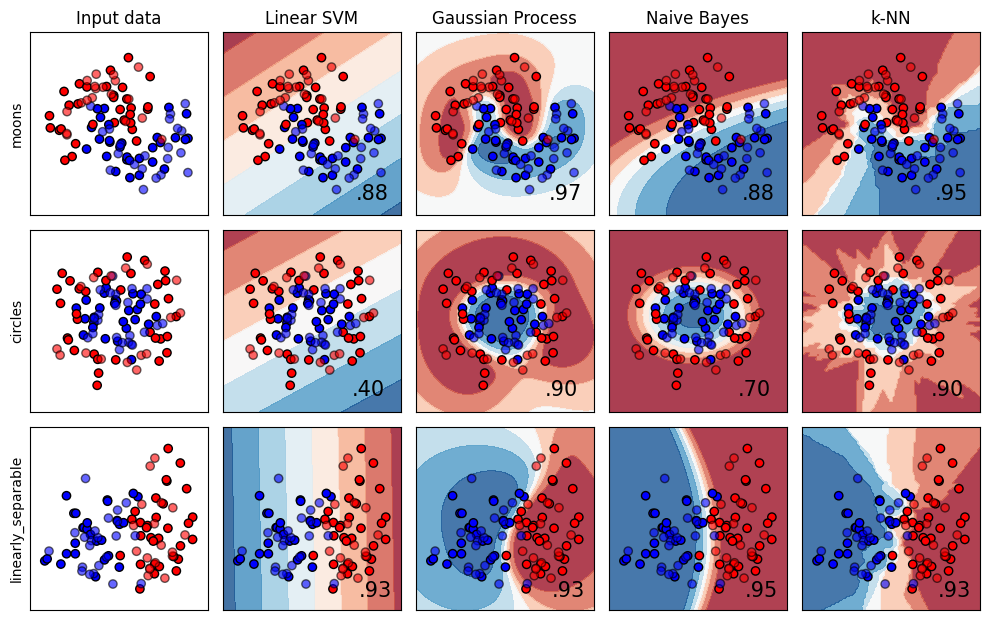

In [3]:
from sklearn.svm import SVC    # Linear SVM
from sklearn.gaussian_process.kernels import RBF    # Radial basis function for Gaussian Process
from sklearn.gaussian_process import GaussianProcessClassifier    # Gaussian Process
from sklearn.naive_bayes import GaussianNB    # Naive Bayes
from sklearn.neighbors import KNeighborsClassifier    # k-NN

from sklearn.datasets import make_circles, make_classification, make_moons

from Part03.classical_algorithms import example_of_algorithms, style_dataframe

classifiers_names = [
    'Linear SVM',
    'Gaussian Process',
    'Naive Bayes',
    'k-NN'
]
classifiers = [
    SVC(kernel='linear', C=0.025, random_state=1),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=1),
    GaussianNB(),
    KNeighborsClassifier(n_neighbors=9),
]

X, y = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]
datasets_names = [
    'moons',
    'circles',
    'linearly_separable',
]

# side effect -> plots everything
results = example_of_algorithms(
    classifiers,
    classifiers_names,
    datasets,
    datasets_names,
)

In [4]:
# create a dataframe of the results
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)
df["dataset"] = pd.Categorical(
    df["dataset"],
    categories=datasets_names,
    ordered=True
)

df.sort_values("classifier", inplace=True)
styled = style_dataframe(
    df,
    [
        ('score', 'high'),
        ('train_runtime', 'low'),
        ('test_runtime', 'low')
    ]
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
Linear SVM,moons,0.875000,0.001143,0.000395
Linear SVM,circles,0.400000,0.000809,0.000325
Linear SVM,linearly_separable,0.925000,0.000747,0.000306
Gaussian Process,moons,0.975000,0.010484,0.000319
Gaussian Process,circles,0.900000,0.010916,0.000355
Gaussian Process,linearly_separable,0.925000,0.094118,0.000330
Naive Bayes,moons,0.875000,0.001589,0.000638
Naive Bayes,circles,0.700000,0.000648,0.000273
Naive Bayes,linearly_separable,0.950000,0.002740,0.000330
k-NN,moons,0.950000,0.000712,0.000971


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATASET_NAME = 'GalaxyMNIST'

results = []
trials = 4
train_size = 1000
test_size = 200
np.random.seed(0)

for name, clf in zip(classifiers_names, classifiers):
    print(f'Starting: {name}')
    for i in range(trials):
        train_start_idx = np.random.randint(0, len(train_flat) - train_size)
        test_start_idx = np.random.randint(0, len(test_flat) - test_size)

        clf_pipeline = make_pipeline(StandardScaler(), clf)

        tr_st = time.perf_counter()
        clf_pipeline.fit(
            train_flat[train_start_idx:train_start_idx + train_size],
            train_labels[train_start_idx:train_start_idx + train_size]
        )
        tr_et = time.perf_counter()
        te_st = time.perf_counter()
        score = clf_pipeline.score(
            test_flat[test_start_idx:test_start_idx + test_size],
            test_labels[test_start_idx:test_start_idx + test_size]
        )
        te_et = time.perf_counter()

        tr_rt = tr_et - tr_st
        te_rt = te_et - te_st
        results.append({
            'classifier': name,
            'dataset': DATASET_NAME, 
            'score': score,
            'train_runtime': tr_rt,
            'test_runtime': te_rt
        })
        print(f'\t{i+1}/{trials} trials', end='\r')
    print(f'\t{trials}/{trials} trials, Done!')
    print(f'Finished: {name}')
print('Done!')

Starting: Linear SVM
	4/4 trials, Done!
Finished: Linear SVM
Starting: Gaussian Process
	4/4 trials, Done!
Finished: Gaussian Process
Starting: Naive Bayes
	4/4 trials, Done!
Finished: Naive Bayes
Starting: k-NN
	4/4 trials, Done!
Finished: k-NN
Done!


In [6]:
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)

styled = style_dataframe(
    df,
    [
        ('score', 'high'),
        ('train_runtime', 'low'),
        ('test_runtime', 'low')
    ]
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
Linear SVM,GalaxyMNIST,0.500000,8.678489,0.854108
Linear SVM,GalaxyMNIST,0.445000,12.030020,1.425615
Linear SVM,GalaxyMNIST,0.535000,16.768867,1.909456
Linear SVM,GalaxyMNIST,0.420000,17.330367,2.330735
Gaussian Process,GalaxyMNIST,0.325000,29.967133,2.500932
Gaussian Process,GalaxyMNIST,0.310000,30.290811,2.510946
Gaussian Process,GalaxyMNIST,0.230000,30.399372,2.513328
Gaussian Process,GalaxyMNIST,0.255000,29.624416,2.506765
Naive Bayes,GalaxyMNIST,0.355000,0.122633,0.023267
Naive Bayes,GalaxyMNIST,0.315000,0.128699,0.023205


In [7]:
df = df.drop(columns=['dataset'], errors='ignore')

g = df.groupby('classifier', as_index=False)
stats_df = g.agg(
    avg_score=('score', 'mean'),
    std_score=('score', 'std'),
    avg_train_runtime=('train_runtime', 'mean'),
    std_train_runtime=('train_runtime', 'std'),
    avg_test_runtime=('test_runtime', 'mean'),
    std_test_runtime=('test_runtime', 'std')
)

stats_df.sort_values('classifier', inplace=True)

styled = style_dataframe(
    stats_df,
    [
        ('avg_score', 'high'),          # high score is good
        ('avg_train_runtime', 'low'),   # low runtime is good
        ('avg_test_runtime', 'low'),    # low runtime is good
        ('std_score', 'low'),           # low std is good
        ('std_train_runtime', 'low'),   # low std is good
        ('std_test_runtime', 'low')     # low std is good
    ]
)
styled = styled.hide(axis='index')

print(f'Using datset: {DATASET_NAME}')
display(styled)

Using datset: GalaxyMNIST


classifier,avg_score,std_score,avg_train_runtime,std_train_runtime,avg_test_runtime,std_test_runtime
Linear SVM,0.475000,0.052122,13.701936,4.106982,1.629979,0.635847
Gaussian Process,0.280000,0.044907,30.070433,0.349461,2.507993,0.005433
Naive Bayes,0.378750,0.053444,0.122112,0.004896,0.023575,0.000430
k-NN,0.472500,0.037969,0.088524,0.021766,0.075402,0.057110


## 3.2 Neural Networks
We will now start to use neural networks to classify the GalaxyMNIST dataset.
### 3.2.1 Multi-Layer Perceptron (MLP)
In this task you will write all the infrastructure to train and evaluate a neural network on a dataset. We recommend using PyTorch, but you can use any other framework as well. You can use [this](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) tutorial to get started and follow the steps below:
- Define a torch dataset (use a `TensorDataset`) and data loaders for the dataset.
- Design a simple fully connected network.
- Write a training loop which computes output, loss and does an optimization step.
- Write an evaluation function that computes the predictions of the trained model on the test set. 
- Plot the training/test loss and accuracy against the number of epochs.


---

The GalaxyMNIST training and testing datasets are imported at the top.
The MLP neural network is defined in a separate `.py` file and imported here.

The model modules/layers are shown below.
The dataset has ($64 \times 64$) RGB images.
This means the model gets an input tensor with the shape ($\mathrm{batch} \times 3 \times 64 \times 64$).
This is first flattened into a ($\mathrm{batch} \times 12288$) matrix.

Then a linear and a ReLU layer transform the input.
This is done twice.
The final layer is again a linear layer, but without a ReLU function.
This produces an output tensor of shape ($\mathrm{batch} \times 4$), because we want to classify the images into four categories.

Between these hidden layers, we also put `nn.Dropout()` layers.
These only affect the training process.
When the model is in training mode, they will randomly set values in the computed tensor to zero.
This prevents neurons from becoming dependent on each other and detecting similar features during the training process.

The training process is done by calling `training_step()` for each epoch, defined in `NN_training.py`.
This function organizes training and testing functions.

`train()` batches the training dataset and runs the model on it.
It applies the given loss function and optimizer to the model during each batch.
It also keeps track of the loss and accuracy and returns these.

`test()` similarly batches the dataset and runs the model, although this time it is on the test dataset.
The results are also saved and returned.

The performance statistics are returned, and we plot these in graphs below.

In order to actually evaluate the model manually, we would simply call it on the test dataset: `MLP_model(test_dataset.data)`.
To convert the predictions into probabilities, the `.softmax()` method would be used.
This is also shown below.
We print the first 20 results.
Since all the outputs are very close to confidences of $1$ that the image is of a certain class, we also decided to find the image which the model is the least confident in classifying.
Displaying the actual image, it makes sense that the model has some trouble deciding between the types of galaxies, as they can be quite indistinct.

Even with low confidences, the model can get the prediction correct, but knowing the accuracy statistic ($<1$) on the test dataset, we must keep in mind that it is not always correct.


In [8]:
from torch import nn
import Part03.MLP_implementation as MLP
from Part03.NN_training import training_loop, loss_and_accuracy_plot

MLP_model = MLP.NeuralNetwork().to(DEVICE)
print(MLP_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=1e-3)

epochs = 15
result: list[dict] = training_loop(
    MLP_model,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs,
    DEVICE,
)

df = pd.DataFrame(result)

  0%|          | 0/15 [00:00<?, ?it/s]

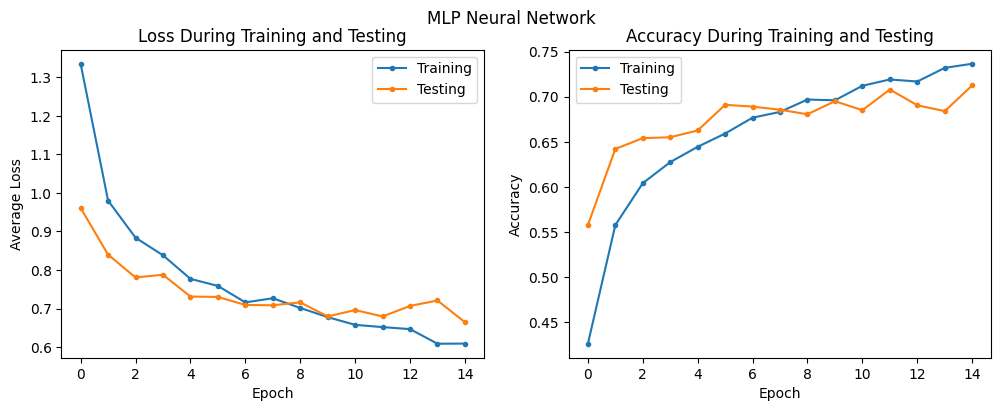

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
loss_and_accuracy_plot(axes, df)
fig.suptitle('MLP Neural Network')

plt.show()

In [11]:
# Evaluating explicitly
MLP_model.eval()
with torch.no_grad():
    probs = MLP_model(test_dataset.data.float())

probs = probs.softmax(dim=1)

confidence, pred = probs.max(dim=1)
idx = confidence.argmin()

num_example = 20
print(f'Example of resulting probabilities for first {num_example} predictions:')
print(probs[:num_example])
print()
print(f'Image with least confident classification:')
print(f'Number id: {idx}')
print(f'Probabilities: {probs[idx]}')
print(f'Classes: {test_dataset.classes}')
print(f'Prediction: {test_dataset.classes[pred[idx]]}')

Example of resulting probabilities for first 20 predictions:
tensor([[9.9853e-01, 5.0491e-12, 1.4657e-03, 4.3325e-13],
        [1.3489e-10, 1.6398e-01, 7.6489e-01, 7.1133e-02],
        [0.0000e+00, 6.8986e-01, 3.1014e-01, 1.4098e-11],
        [3.1829e-08, 6.5340e-02, 9.3466e-01, 3.5921e-10],
        [1.0000e+00, 1.6836e-30, 1.3331e-14, 2.0850e-28],
        [8.0727e-09, 2.7220e-10, 9.9990e-01, 1.0094e-04],
        [0.0000e+00, 1.9714e-03, 9.9616e-01, 1.8701e-03],
        [5.5635e-22, 9.7488e-05, 9.9990e-01, 3.0134e-09],
        [0.0000e+00, 2.0148e-07, 1.0000e+00, 9.7266e-12],
        [9.9976e-01, 6.9339e-19, 2.3562e-04, 2.6474e-14],
        [2.5319e-11, 8.4526e-01, 1.5474e-01, 4.2622e-07],
        [1.0000e+00, 1.2611e-40, 2.2840e-17, 2.6813e-26],
        [0.0000e+00, 2.4093e-04, 9.9971e-01, 4.7674e-05],
        [1.5929e-06, 1.2338e-34, 1.0000e+00, 1.0765e-28],
        [6.2444e-04, 2.5226e-12, 9.9937e-01, 7.7950e-07],
        [2.9789e-05, 1.5418e-01, 8.4545e-01, 3.3993e-04],
        [3.

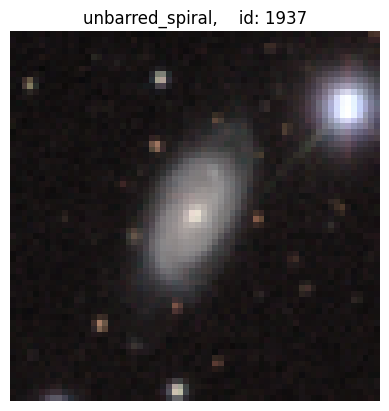

In [12]:
from Part01.visualization import show_galaxy

fig, ax = plt.subplots()
show_galaxy(
    test_dataset.data[idx],
    ax,
    f'{test_dataset.classes[test_dataset.targets[idx]]},    id: {idx}')
plt.show()

### 3.2.2 CNN
MLPs are a simple form of neural networks. However, inserting prior knowledge about the structure of the data can help improve the performance. Convolutional Neural Networks (CNNs) are a type of neural network that is well-suited for image classification tasks.
- Design a CNN and train it on the dataset.
- Can an MLP learn to act like a CNN?

---

We will again use the GalaxyMNIST training and testing datasets.
The CNN neural network is defined in a separate `.py` file and imported here.

The model modules/layers are shown below.
Like before, the model gets an input tensor with the shape ($\mathrm{batch} \times 3 \times 64 \times 64$) (an RGB image with $64 \times 64$ pixel resolution).
Unlike an MLP, a CNN exploits the image structure, so this time the input is *not* flattened at the start.
Instead, a sequence of convolution, `ReLU()` and `MaxPool2d()` operations are done on the input.

- The convolution operations produce multiple channels of output, corresponding to the number of kernels selected.
- The `ReLU()` operation introduces nonlinearity behavior, like explained previously.
- The `MaxPool2d()` calls operate on "windows" of the previous tensor to calculate new values, but they specifically pick the maximum value.
This introduces more nonlinearity and also shrinks the "spatial dimensions" of the image tensor, while keeping channels separate (see table below).

After these, we finally flatten the data tensor and do a final stage of linear/ReLU transformations on it to end up with $4$ different output channels per image in the batch, corresponding to the four different galaxy type labels which we want to assign.
In this final stage, we also include one `Dropout()` layer like in the MLP model.
This should again prevent overfitting and make neurons learn features in a more independent and varied way.

The specific hyperparameters of the layers are printed in the model initialization code below.
The shape of the input after each layer is given here:

\begin{align*}
    & \text{Layer} && \text{Shape After Applying} \\ \hline \hline
    & \text{Input: } && (\mathrm{batch}, 3, 64, 64) \\
    & \text{Conv2d and ReLU: } && (\mathrm{batch}, 32, 64, 64) \\
    & \text{MaxPool2d: } && (\mathrm{batch}, 32, 32, 32) \\
    & \text{Conv2d and ReLU: } && (\mathrm{batch}, 64, 32, 32) \\
    & \text{MaxPool2d: } && (\mathrm{batch}, 64, 16, 16) \\
    & \text{Flatten: } && (\mathrm{batch}, (64 \cdot 16 \cdot 16)) \\
    & \text{Linear and ReLU: } && (\mathrm{batch}, 128) \\
    & \text{Linear: } && (\mathrm{batch}, 4)
\end{align*}

The training loop is the same as before, and we pass the same loss function and optimizer for simplicity.
We graph loss and accuracy during the training process below.

We see better accuracy with this model compared to the MLP NN.
An MLP is more general than a CNN, but the convolutional approach fits well with the image classification task.
With enough training time/data and parameters/layer tuning, the MLP model could probably act like a CNN as well.
However, this would take more parameters and effort, as we will see in the next part.

In [13]:
import Part03.CNN_implementation as CNN

CNN_model = CNN.Neural_Network().to(DEVICE)
print(CNN_model)

Neural_Network(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNN_model.parameters(), lr=1e-4)

result = []

epochs = 15
result: list[dict] = training_loop(
    CNN_model,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs,
    DEVICE,
)

df = pd.DataFrame(result)

  0%|          | 0/15 [00:00<?, ?it/s]

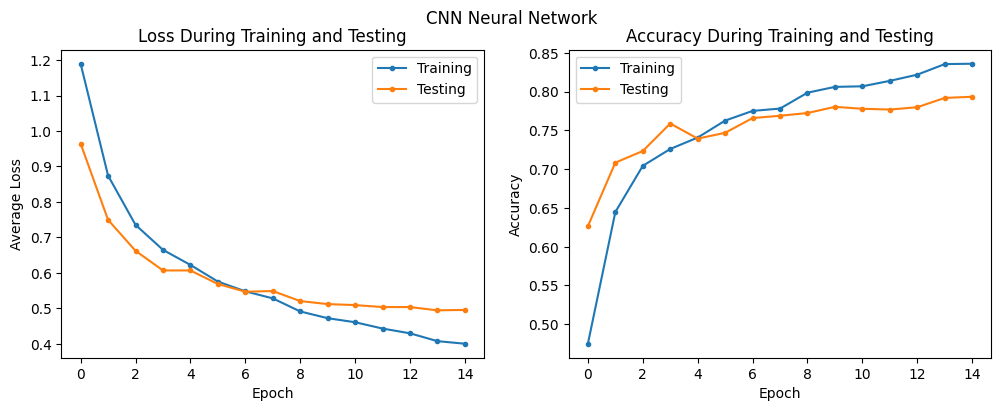

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
loss_and_accuracy_plot(axes, df)
fig.suptitle('CNN Neural Network')

plt.show()

## 3.2.3 Model Analysis
- Print how many parameters each neural network has.
- Does more parameters always mean better performance?

---

Below we define a function to print an organized list of the parameter structure of our neural networks.
We see that the MLP model has a total of $6,556,676$ parameters.
The CNN model has a total of $2,117,188$.

In terms of accuracy on the test dataset, we see that more parameters does not guarantee a better model.
The MLP model has three times as many parameters and similar to worse accuracy.

Clearly the module structure of the neural network is important to its performance in the image classification task.

In [16]:
def NN_param_summary(
        model: nn.Module,
        show_empty_modules: bool = False
    ) -> None:
    '''
    Print a list/summary of neural network layers with their names.
    Includes layers with no trainable parameters (e.g. nn.ReLU()).
    '''
    total_num: int = 0

    for name, module in model.named_modules():
        if name == '': continue    # first entry is always the model itself, with empty string as name, (no parameters)
        params = list(module.parameters(recurse=False))

        if (len(params) == 0) and (not show_empty_modules): continue    # detect empties, go to next loop if we dont want to see them

        print(f'{name}:')
        if len(params) == 0:
            print('\t(no parameters)')
        else:
            for param_name, param in module.named_parameters(recurse=False):
                n = param.numel()
                print(f'\t{param_name}:')
                print(f'\t\tShape: {tuple(param.shape)}')
                print(f'\t\tNumber: {n:,}')
                total_num += n
    print(f'-----------------------------------\nTotal parameters: {total_num:,}')

print('MLP Model:')
NN_param_summary(MLP_model)

MLP Model:
linear_relu_stack.0:
	weight:
		Shape: (512, 12288)
		Number: 6,291,456
	bias:
		Shape: (512,)
		Number: 512
linear_relu_stack.3:
	weight:
		Shape: (256, 512)
		Number: 131,072
	bias:
		Shape: (256,)
		Number: 256
linear_relu_stack.6:
	weight:
		Shape: (4, 256)
		Number: 1,024
	bias:
		Shape: (4,)
		Number: 4
-----------------------------------
Total parameters: 6,424,324


In [17]:
print('CNN Model:')
NN_param_summary(CNN_model)

CNN Model:
conv_layers.0:
	weight:
		Shape: (32, 3, 3, 3)
		Number: 864
	bias:
		Shape: (32,)
		Number: 32
conv_layers.3:
	weight:
		Shape: (64, 32, 3, 3)
		Number: 18,432
	bias:
		Shape: (64,)
		Number: 64
classifier.1:
	weight:
		Shape: (128, 16384)
		Number: 2,097,152
	bias:
		Shape: (128,)
		Number: 128
classifier.4:
	weight:
		Shape: (4, 128)
		Number: 512
	bias:
		Shape: (4,)
		Number: 4
-----------------------------------
Total parameters: 2,117,188


### 3.2.4 Hyperparameter Tuning
- Use your best model and try to improve its performance by changing its architecture. Possible changes include:
    - Normalization Layers
    - Regularization (Optimizer or Layers)
    - Different Activation Functions
    - Different Learning Rates
    - Increase the number of layers or neurons
- Report which changes seem effective and which do not.

---

We chose the CNN model as a base to improve upon.

Adding normalization layers with `BatchNorm2d()` within the convolution layers seems to increase accuracy, so we made this modification to the CNN.
This is a general observation, it is difficult to know and test how exact positions of the layer within the sequence of steps affects accuracy.
Having this layer in between the convolution layers but before the last layer and the flatten/fully connected layers seems best.

Regularization is the process of making sure a model is not overfitting by "memorizing the data", or learning overly complicated artifacts in the training data.
Approaches like adding `Dropout()` layers (as we already have above) and giving the optimizer a `weight_decay` parameter are parts of regularization.
In the optimized approach, we added a decay to the weights to disproportionately reduce large weights.
This forces the model to "spread out" the weights and information more evenly and not rely on single, high weighted neurons for most of the output.
We see that this generally reduces the gap between training and test accuracy.

Different activation functions such as `LeakyReLU()` were tried, but we did not see any noticeable differences, so we kept the simpler `ReLU()` version.
In principle, these would help the model achieve a better accuracy in training by making it less likely for a model to develop "dead neurons" which are always set to zero by the `ReLU()` function and do not contribute to the output under any inputs.

We also noticed that decreasing the learning rate (compared to the MLP model) helped the model learn better during the training process, so this was also done for the training process of our optimized model.
This stops the optimizer from taking steps in the parameters which are too large, which would cause it to oscillate around the optimal parameters and not converge properly.

Obviously increasing the number of channels/neurons would increase the complexity of the model and generally lead to better accuracy on the training data, but this comes with runtime/performance costs, so we cannot scale up too much.
In addition, adding too many layers/parameters risks overfitting to the training data, which was seen as an increase in loss over the training epochs while we tried to optimize the hyperparameters.
We did decide to add another convolution/`BatchNorm()`/`ReLU()` layer in the optimized neural network to increase its complexity and hopefully allow it to model more complex functions better, while making sure that the model is not overfitting too much by comparing test and training accuracy.




In [18]:
CNN_model_optimized = CNN.Neural_Network_Optimized().to(DEVICE)
print(CNN_model_optimized)

Neural_Network_Optimized(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, b

In [19]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNN_model_optimized.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 15
result: list[dict] = training_loop(
    CNN_model_optimized,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs,
    DEVICE,
)

df = pd.DataFrame(result)

  0%|          | 0/15 [00:00<?, ?it/s]

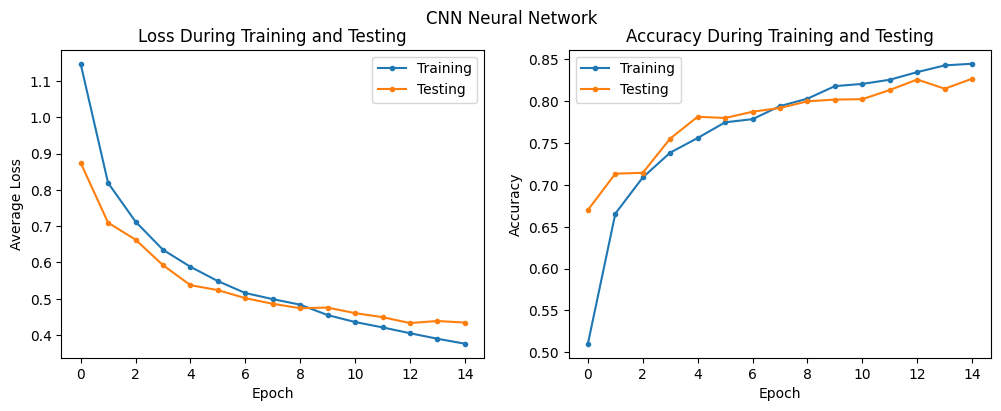

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
loss_and_accuracy_plot(axes, df)
fig.suptitle('CNN Neural Network')

plt.show()

In [21]:
NN_param_summary(CNN_model_optimized)

conv_layers.0:
	weight:
		Shape: (32, 3, 3, 3)
		Number: 864
	bias:
		Shape: (32,)
		Number: 32
conv_layers.1:
	weight:
		Shape: (32,)
		Number: 32
	bias:
		Shape: (32,)
		Number: 32
conv_layers.4:
	weight:
		Shape: (64, 32, 3, 3)
		Number: 18,432
	bias:
		Shape: (64,)
		Number: 64
conv_layers.5:
	weight:
		Shape: (64,)
		Number: 64
	bias:
		Shape: (64,)
		Number: 64
conv_layers.8:
	weight:
		Shape: (32, 64, 3, 3)
		Number: 18,432
	bias:
		Shape: (32,)
		Number: 32
classifier.1:
	weight:
		Shape: (128, 2048)
		Number: 262,144
	bias:
		Shape: (128,)
		Number: 128
classifier.4:
	weight:
		Shape: (4, 128)
		Number: 512
	bias:
		Shape: (4,)
		Number: 4
-----------------------------------
Total parameters: 300,836


### 3.2.5 Evaluation on the test set
You have now tuned the model hyperparameters to achieve the best accuracy on the test set.
- Why can it become problematic to tune hyperparameters on the test set? What are possible solutions to keep this overfitting in check?

---

Tuning the hyperparameters on the test set means that it is can no longer be considered an independent test of the data.
We specifically chose the hyperparameters to make accuracy on the test dataset high.
This means we risk overfitting the test set, meaning the model is worse when it sees new data.
This is analogous to the training process itself, where we train on the training data but need the test dataset to monitor the model's learning progress.

To solve this problem, we could tune the hyperparameters on some test dataset but keep a *second* similarly sized test dataset.
This one would only be given to the model to at the end of training, to truly evaluate its performance on new, unseen, and independent data.